In [1]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 19.3 MB/s eta 0:00:00


In [40]:
import pandas as pd
from konlpy.tag import Okt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [17]:
from google.colab import files
uploaded = files.upload()

Saving notices_fixed.csv to notices_fixed.csv


In [18]:
df = pd.read_csv("notices_fixed.csv")

In [26]:
df["text"] = (
    df["title"].fillna("") +
    " " +
    df["content"].fillna("")
)

okt = Okt()
stopwords = [
    "공지",
    "안내",
    "문의",
    "학생",
    "대학",
    "관련",
    "운영",
    "신청",
    "지원",
    "참여",
    "대상"
]
def tokenizer(text):

    nouns = okt.nouns(text)

    result = [
        word
        for word in nouns
        if len(word) > 1 and word not in stopwords
    ]

    return result

In [41]:
vectorizer = TfidfVectorizer(
    tokenizer=tokenizer,
    max_features=3000
)

X = vectorizer.fit_transform(df["text"])
y = df["category"]

X_train, X_test, y_train, y_test, title_train, title_test = train_test_split(
    X,
    y,
    df["title"],
    test_size=0.2,
    random_state=42
)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [43]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

In [44]:
print("정확도:", accuracy)
result_df = pd.DataFrame({
    "제목": title_test.values,
    "실제 category": y_test.values,
    "예측 category": predictions
})
print(result_df.head(30))

정확도: 0.8652173913043478
                                                   제목  실제 category  \
0               2025학년도 1학기 '적성기반 취업 준비반 프로그램' 참여자 모집      program   
1                2025 SW중심대학 연합 SW 페스티벌 행사 안내 (11/20)        event   
2           2020년도 기상기후산업 청년창업 지원사업 예비창업팀 모집 공고(기한연장)     academic   
3               [국제교류팀] 2024년도 동계 국제화연수(UoG) 선발 4차 공고      program   
4   [미래인재센터] 글로벌 역량 강화 교육 플랫폼 '링크드인 러닝   (Linkedin...      program   
5                   2025학년도 후기(2026년 8월) 예비졸업사정 시행 안내     academic   
6                        2024년 경희대학교 SW아너십 모집 (~3/27)     academic   
7                     2023년 실리콘밸리 Spirent 해외 인턴십 신청안내          job   
8                        [마감] 2019년 다빈치 SW 메이커페스티벌 개최        event   
9           [홍보] 2023 'KT랜선 야학' 인천/경기 지역 대학생 멘토 선발 안내        event   
10                                         (주)리턴 신규채용          job   
11                          [인권센터] 제3회 인권작품 공모전 공모 안내        event   
12                    [홍보] 미국 아마존 마켓플레이스 운영 실습 교육생 모집      program

In [34]:
test_notices = [
    "카카오 채용 연계형 인턴 모집",
    "2025학년도 2학기 수강신청 안내",
    "AI 해커톤 참가자 모집"
]

test_tfidf = vectorizer.transform(test_notices)
predictions = model.predict(test_tfidf)
for text, pred in zip(test_notices, predictions):

    print("공지:", text)
    print("예측:", pred)
    print("=" * 50)

공지: 카카오 채용 연계형 인턴 모집
예측: job
공지: 2025학년도 2학기 수강신청 안내
예측: academic
공지: AI 해커톤 참가자 모집
예측: event


카카오 채용 연계형 인턴 모집
job
2025학년도 2학기 수강신청 안내
academic
AI 해커톤 참가자 모집
event


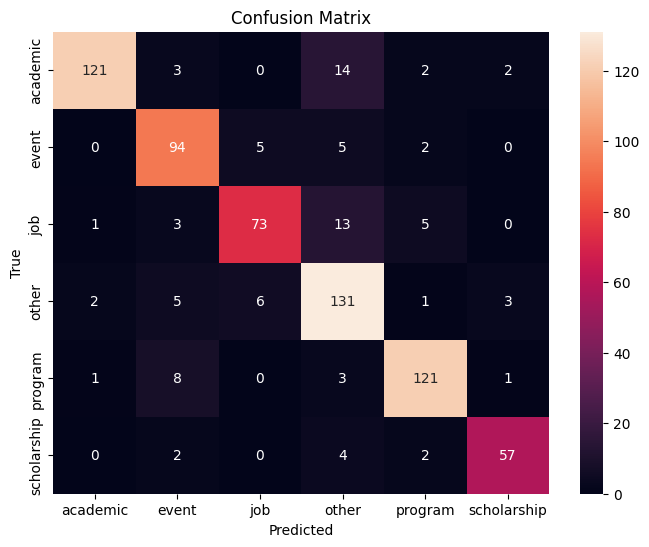

In [45]:
#성능 시각화(발표자료)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

new_predictions = model.predict(test_tfidf)
for text, pred in zip(test_notices, new_predictions):
    print(text)
    print(pred)

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [33]:
# 새로운 공지사항 테스트

new_notice = """
삼성전자 AI 해커톤 참가자 모집 안내

삼성전자에서 AI 해커톤 참가자를 모집합니다.
우수 참가자에게는 채용 연계 기회가 제공됩니다.
"""

new_tfidf = vectorizer.transform([new_notice])
probs = model.predict_proba(new_tfidf)[0]
categories = model.classes_

threshold = 0.3
multi_tags = []
print("===== category별 확률 =====")

for category, prob in zip(categories, probs):
    print(category, ":", round(prob, 3))
    if prob >= threshold:
        multi_tags.append(category)
print("\n최종 태그:", multi_tags)

===== category별 확률 =====
academic : 0.021
event : 0.638
job : 0.188
other : 0.082
program : 0.052
scholarship : 0.019

최종 태그: ['event']
